In [ ]:
import tensorflow as tf
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =====================================================
# NOTEBOOK-SAFE PATH SETUP  ✅
# =====================================================
# In notebooks, __file__ does NOT exist
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
sys.path.append(str(PROJECT_ROOT))

from data_pipeline import train_ds, test_ds

# =====================================================
# LOAD AUTOENCODER MODEL  ✅
# =====================================================
MODEL_DIR = PROJECT_ROOT / "model"
model_path = MODEL_DIR / "con_aen_model.keras"
encoder_model_path = MODEL_DIR / "con_aen_encoder_model.keras"

if not model_path.exists():
    raise FileNotFoundError(f"Model file not found at: {model_path}")

print(f"Loading autoencoder model from {encoder_model_path}")
autoencoder_model = tf.keras.models.load_model(model_path)

# =====================================================
# SAFE DATA EXTRACTION (NO ZEROING, NO SHUFFLE LOSS) ✅
# =====================================================
def get_data_and_labels(dataset):
    images, labels = [], []
    for batch_imgs, batch_labels in dataset:
        images.append(batch_imgs.numpy())
        labels.append(batch_labels.numpy())

    X = np.concatenate(images, axis=0)
    y = np.concatenate(labels, axis=0).reshape(-1)

    return X, y

print("Extracting data and labels...")
X_train, y_train = get_data_and_labels(train_ds)
X_test, y_test   = get_data_and_labels(test_ds)

print(f"Train samples: {X_train.shape}, Test samples: {X_test.shape}")

# =====================================================
# SANITY CHECK (CRITICAL) 🔍
# =====================================================
print("X_train min:", X_train.min(), "max:", X_train.max())
print("X_test  min:", X_test.min(),  "max:", X_test.max())

# =====================================================
# GENERATE RECONSTRUCTIONS  ✅
# =====================================================
print("Generating reconstructed images...")
X_train_recon = autoencoder_model.predict(X_train, batch_size=32)
X_test_recon  = autoencoder_model.predict(X_test, batch_size=32)
print("Reconstruction complete.")

# Ensure proper visualization range
X_train_recon = np.clip(X_train_recon, 0.0, 1.0)
X_test_recon  = np.clip(X_test_recon, 0.0, 1.0)

# Extracting latent features
encoder_model = tf.keras.models.load_model(encoder_model_path)

X_train_feat = encoder_model.predict(X_train,  batch_size=32)
X_test_feat  = encoder_model.predict(X_test,  batch_size=32)
X_train_feat = np.clip(X_train_feat, 0.0, 1.0)
X_test_feat  = np.clip(X_test_feat, 0.0, 1.0)

# =====================================================
# VISUALIZATION FUNCTION  ✅
# =====================================================
def plot_reconstructions(original, reconstructed, n=5):
    plt.figure(figsize=(3*n, 6))

    for i in range(n):
        # Original
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i])
        plt.title("Original")
        plt.axis("off")

        # Reconstructed
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i])
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("Plotting sample reconstructions from test set...")
plot_reconstructions(X_test, X_test_recon, n=5)



mean_fresh  = X_train_recon[y_train == 0].mean(axis=0)
mean_rotten = X_train_recon[y_train == 1].mean(axis=0)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Mean Fresh Recon")
plt.imshow(mean_fresh)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Mean Rotten Recon")
plt.imshow(mean_rotten)
plt.axis("off")
plt.show()


Loading autoencoder model from /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/model/con_aen_encoder_model.keras
Extracting data and labels...


2026-01-18 11:59:15.879111: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/dataset_1/Train/rottenapples/a_r006.png; No such file or directory
2026-01-18 11:59:15.879246: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/dataset_1/Train/rottenapples/a_r004.png; No such file or directory
2026-01-18 11:59:15.879295: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/dataset_1/Train/freshapples/a_f007.png; No such file or directory
2026-01-18 11:59:15.879325: W tensorflow/core/framework/op_kernel.cc:1855] OP_REQUIRES failed at whole_file_read_ops.cc:117 : NOT_FOUND: /home/aishwarya/Do

NotFoundError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} /home/aishwarya/Documents/colz/Msc-DSCI/Modules/Artificial Neural Network/src/dataset_1/Train/rottenapples/a_r010.png; No such file or directory
	 [[{{node ReadFile}}]] [Op:IteratorGetNext] name: 

Loading CNN classifier model...

Loading Banana Dataset for Prediction...
Found 600 files belonging to 2 classes.
Extracted 600 banana samples.

Sample Predictions on Banana Data:
0.4502364
Sample 245: True=Healthy, Pred=Healthy (54.98% confidence)
0.5707336
Sample 128: True=Rotten, Pred=Healthy (42.93% confidence)
0.9312315
Sample 9: True=Rotten, Pred=Rotten (93.12% confidence)
0.878811
Sample 171: True=Rotten, Pred=Rotten (87.88% confidence)
0.778146
Sample 151: True=Healthy, Pred=Rotten (77.81% confidence)


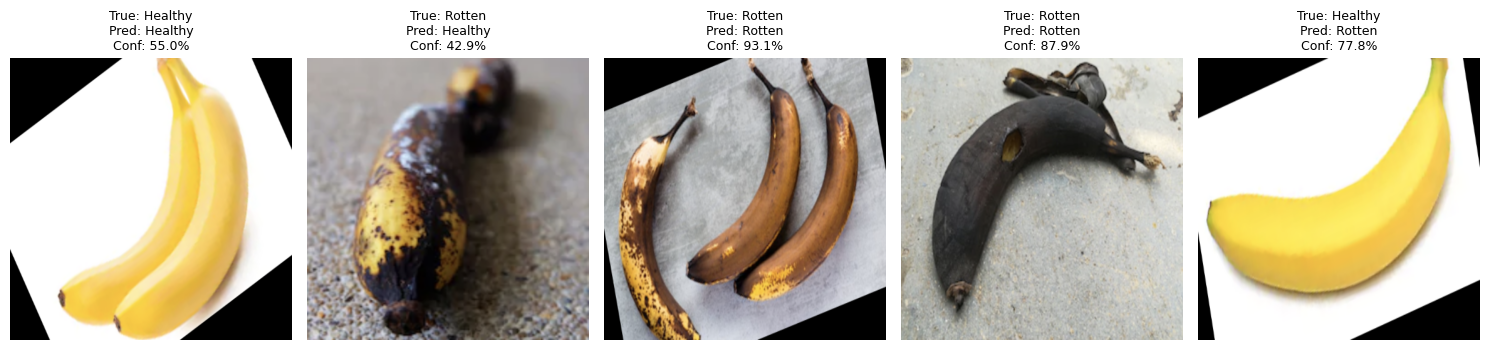

In [5]:
import tensorflow as tf
from os import path as os_path
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- PATH SETUP ----------
# Project root
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
sys.path.append(str(PROJECT_ROOT))  # Add project root to import data_pipeline

from data_pipeline import load_fruit_dataset, normalize

# Model paths
MODEL_DIR = PROJECT_ROOT / "model"
# Autoencoder path (commented, kept as placeholder)
aen_model_path = MODEL_DIR / "con_aen_model.keras"
# CNN classifier path
cnn_model_path = MODEL_DIR / "cnn_classifier_model.keras"

# Dataset path
DATASET_PATH = PROJECT_ROOT / "data/prediction_use_dataset"

# ---------- LOAD CNN CLASSIFIER ----------
print("Loading CNN classifier model...")
cnn_classifier_model = tf.keras.models.load_model(cnn_model_path)

# ---------- LOAD BANANA TEST DATA ----------
print("\nLoading Banana Dataset for Prediction...")
banana_test_ds = load_fruit_dataset(DATASET_PATH / "Test", "banana")
banana_test_ds = banana_test_ds.map(normalize)

# ---------- EXTRACT IMAGES AND LABELS ----------
def get_data_and_labels(dataset):
    images = []
    labels = []
    for img, label in dataset.as_numpy_iterator():
        images.append(img)
        labels.append(label)
    return np.concatenate(images, axis=0), np.concatenate(labels, axis=0)

X_banana, y_banana = get_data_and_labels(banana_test_ds)
print(f"Extracted {len(X_banana)} banana samples.")

# ---------- SAMPLE PREDICTIONS & VISUALIZATION ----------
print("\nSample Predictions on Banana Data:")

num_samples = 5
indices = np.random.choice(len(X_banana), num_samples, replace=False)

plt.figure(figsize=(15, 4))
for idx, i in enumerate(indices):
    img = X_banana[i:i+1]
    true_label = "Rotten" if y_banana[i] == 1 else "Healthy"
    
    # Prediction
    prediction = cnn_classifier_model.predict(img, verbose=0)[0][0]
    print(prediction)
    pred_label = "Rotten" if prediction > 0.7 else "Healthy"
    confidence = prediction if prediction > 0.7 else 1 - prediction
    
    print(f"Sample {i}: True={true_label}, Pred={pred_label} ({confidence*100:.2f}% confidence)")
    
    # Plot image
    plt.subplot(1, num_samples, idx+1)
    plt.imshow(np.squeeze(img))  # Remove batch dimension
    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence*100:.1f}%", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# ---------- OVERALL EVALUATION ----------
# print("\nOverall Evaluation on Banana Test Set:")
# loss, acc = cnn_classifier_model.evaluate(X_banana, y_banana, verbose=1)
# print(f"Banana Accuracy: {acc*100:.2f}%")

